# Identification of factors

In this notebook, we use the already trained DRVI model on the immune dataset to show different ways to identify a factor. In summary we can:

- Identify based on available annotation
- Identify using GSEA
- Identify using Language models
- Looking into the annotation databases

**We always advise examination by a biologist or looking into the published litereture for validation of the identified processes.**

## Intro

In this notrbook, we assume that the user has already trained DRVI on Immune data.

Please refer to [General training and interpretability pipeline](./general_pipeline.html) tutorial.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, next cell will install dependencies.

Please remove this part if your environment is already setup.

In [68]:
import sys

# if branch is stable, will install via pypi, else will install from source
branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    !pip install multigrate[tutorials]
elif IN_COLAB and branch != "stable":
    !pip install git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]

## Imports

In [69]:
import warnings
warnings.filterwarnings("ignore")

In [70]:
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [71]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.2


## Config

In [72]:
# Set this to false if you already trained your model and do not like to retrain.
overwrite = False
SEED = 1  # Set to None if you don't want to set seed

# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/")
io_dir.mkdir(parents=True, exist_ok=True)
io_dir

PosixPath('tmp_io/drvi_immune_128')

## Load Data

In [73]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad("/home/icb/clara.sanchez/workspace/data/drvi_immune_128/adata_preprocesses.h5ad")

## Load DRVI ouputs

In [74]:
model_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/drvi_model"
embed_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/embed.h5ad"
traverse_adata_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File /home/icb/clara.sanchez/workspace/data/drvi_immune_128/drvi_model/model.pt already downloaded        
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.2.                                  
INFO     DRVI: Loading model from DRVI version 0.2.1.                                                              
INFO     DRVI: Modifying model args from 0.2.1 to 0.2.2 (no user action required)                                  
INFO     DRVI: Removing prior_init_obs from model args.                                                            
INFO     DRVI: Done updating model args. Loading in 0.2.2.                                                         
INFO     DRVI: The model has been initialized                           

## Identify based on available annotations

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

In [75]:
annot_col = "final_annotation"

### Specific Imports

In [76]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

### Helper functions

In [77]:
def plot_packed_network(df, title_col='title', var_col='variable', val_col='value'):
    """
    Visualizes network with edge weights shown to 2 decimal places.
    """
    # Create Graph
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)
    
    # Custom Grid Layout Logic
    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components)**0.5)
    
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    
    # Draw Nodes & Edges
    nx.draw(G, pos, 
            with_labels=True, font_size=8, font_weight='bold', node_size=600,
            node_color=['#A0CBE2' if n in titles else '#FF9E9E' for n in G.nodes()],
            width=[d[val_col] * 4 for u, v, d in G.edges(data=True)], 
            edge_color='grey', alpha=0.6)
    
    # Draw Edge Labels (Weights rounded to 2 decimals)
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
            
    plt.axis('off')
    plt.show()

### Code

In [78]:
# Remove vanished dimensions
embed_nv = embed[:, embed.var['vanished'] == False].copy()
embed_nv

AnnData object with n_obs × n_vars = 32484 × 61
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [79]:
benchmark = DiscreteDisentanglementBenchmark(
    embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"],
)
benchmark.evaluate()
# You can optionally save benchmark object if you want.
# benchmark.save(filename)
# benchmark = DiscreteDisentanglementBenchmark.load(filename, embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs["final_annotation"], metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"])

In [80]:
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity[:5]  # only showing 5 rows

,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [81]:
filtering_threshold = 0.5

top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars='title', value_vars=smi_similarity.columns)
    .query("value >= @filtering_threshold")
    .reset_index(drop=True)
)
top_matches

,title,variable,value
0,DR 1,CD4+ T cells,0.535119
1,DR 41,CD10+ B cells,0.668039
2,DR 53,CD10+ B cells,0.773828
3,DR 31,CD10+ B cells,0.659314
4,DR 2,CD14+ Monocytes,0.761070
5,DR 3,CD14+ Monocytes,0.878655
6,DR 26,CD16+ Monocytes,0.661827
7,DR 9,CD16+ Monocytes,0.910748
8,DR 5,CD20+ B cells,0.758002
9,DR 7,CD20+ B cells,0.654006


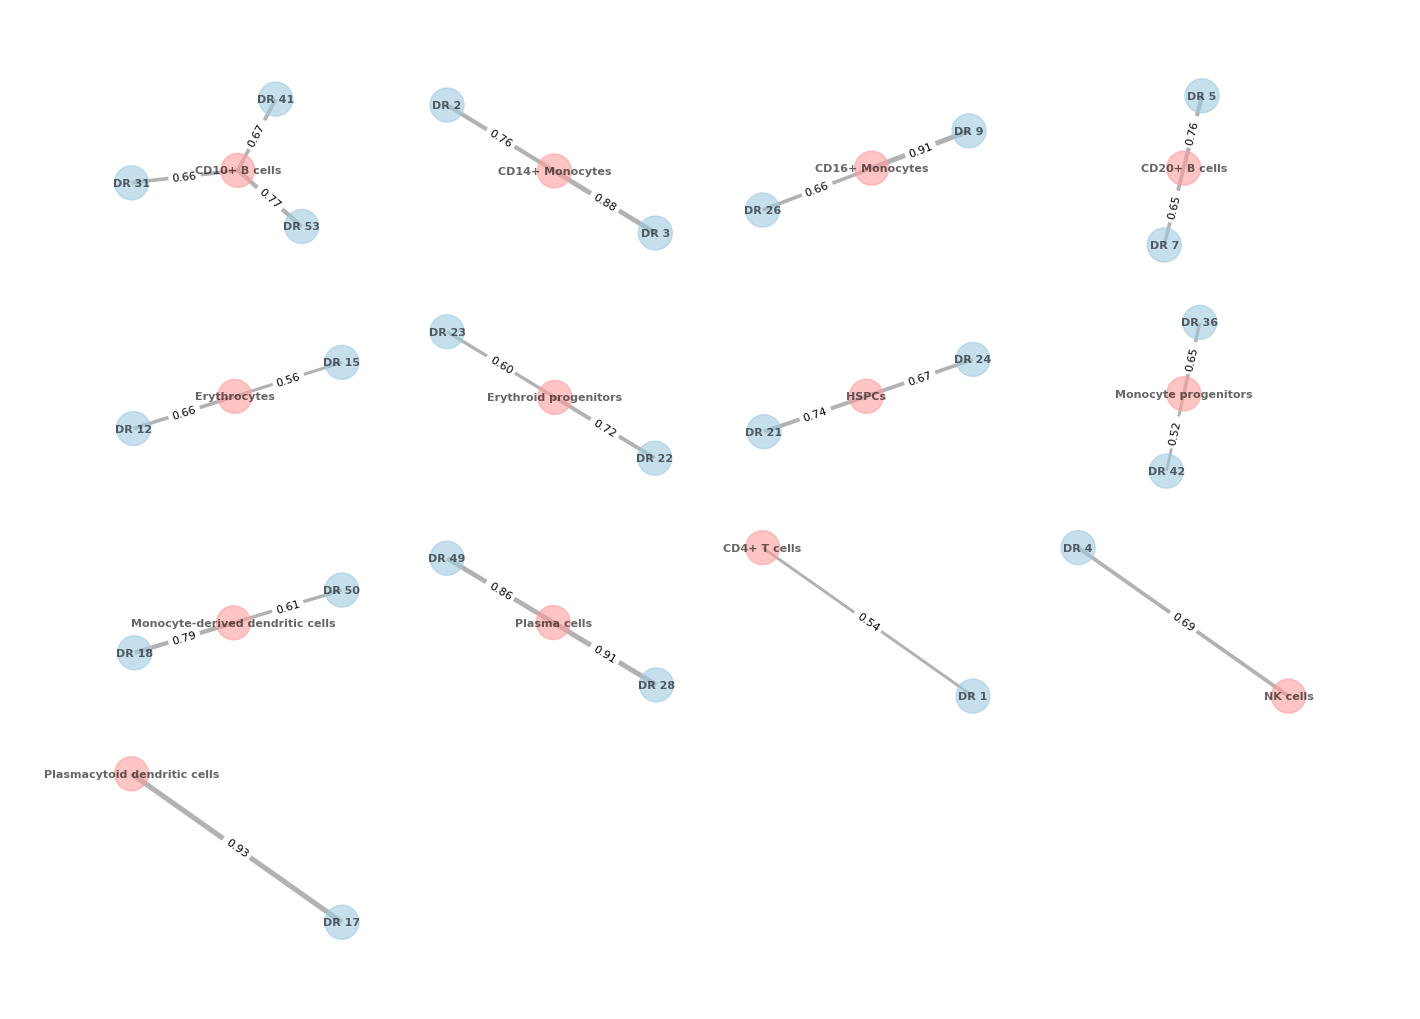

In [82]:
plot_packed_network(top_matches)

#### Heatmap

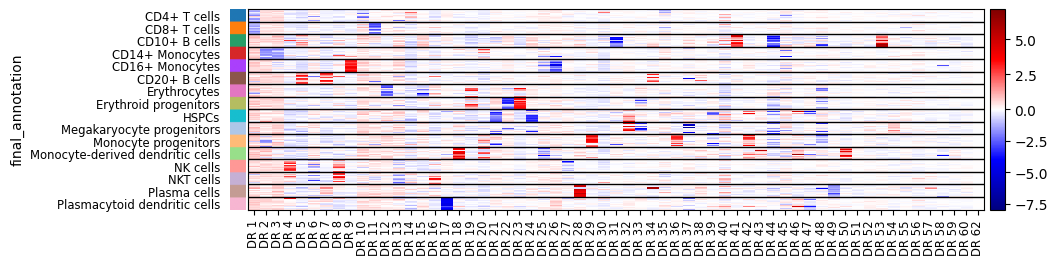

In [83]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title")

It is possible to sort dimensions based on the top relevance with respect to a categoricals variable

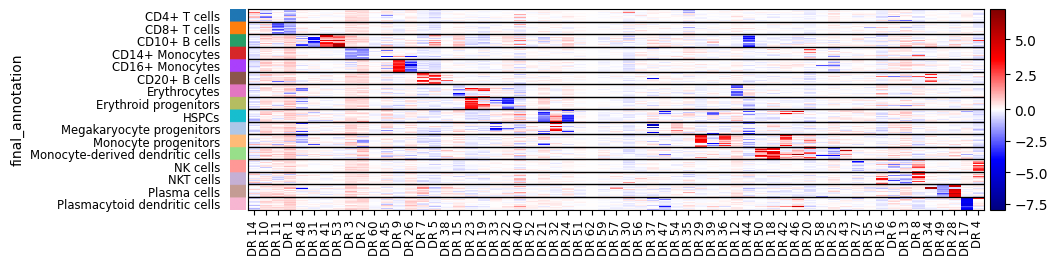

In [84]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title", sort_by_categorical=True)

## Identification of programs

Once we identify the top relevant genes, we can determine some programs through supervised external information, such as:
- existing annotations
- examination by biologists
- gene-set enrichment analysis (GSEA)
- scientific literature
- automated tools based on language models

**Please refer to this tutorial for some tools that we found useful for identification of programs**

It is worth mentioning that since such supervised information is not given to the model, the quality of the derived signatures is neither affected nor biased by it. Unidentified processes with high gene scores are promising candidates for further literature search, additional analysis, and even experimental design.

1. Input: 
-Gene list?
-Ranked list?
Expression Correlation with known Zelltype Markers
2. Reference Databases: 
-Classic Datatabases: Gene Ontology, Reactome, MSigDB? 
-Celltype specific Data (Cell Typist)
-LLMs: gsai?
3. Annotation Method:
-Over-representation
-Regressions based: How well does a set of genes explain a factor




# Exploration Roadmap: DRVI Factor Annotation Pipeline

This roadmap outlines the systematic evaluation of tools for annotating latent factors. The goal is to move from abstract dimensions to interpretable biological processes using the immune dataset as a pilot.

## General Roadmap Settings


### Shared Imports

In [ ]:
import re

import blitzgsea as blitz
import celltypist
import decoupler as dc
import gseapy as gp
import numpy as np
import pandas as pd
import seaborn as sns
from celltypist import models
from gprofiler import GProfiler

### General Configurations and Settings

#### Gene preprocessing

In [86]:
GENE_CASE = "upper"  # Normalize gene symbols to uppercase for cross-database matching
TOP_N = 300 # Number of top-ranked genes per factor used as input for ORA tools (g:Profiler)
FDR = 0.05 # False Discovery Rate threshold for significance across all tools

In [146]:
# CellTypist
CT_CORR_THRESHOLD = 0.40 # Minimum Pearson correlation between factor and cell-type probability
CT_SPEC_THRESHOLD = 0.10 # Minimum specificity (gap between best and second-best correlation)

# GSEA tools (blitzgsea / gseapy)
GSEA_DB = "MSigDB_Hallmark_2020"
GSEAPY_MIN_SIZE = 10
GSEAPY_MAX_SIZE = 500
GSEAPY_PERMUTATIONS = 1000
BLITZGSEA_PROCESSES = 4

# g:Profiler
GP_ORGANISM = "hsapiens"
GP_SOURCES = None
GP_USER_THRESHOLD = 0.05
GP_ORDERED = False

# decoupler
DC_ORGANISM = "human"  # "human" or "mouse"
DC_GENESET = "msdib_hallmark"
DC_METHODS = ["ulm", "mlm", "zscore"]
DC_USE_CONSENSUS = True
DC_PRIMARY_METHOD = "ulm"
DC_TMIN = 5

# mLLM CellType
MLLM_SPECIES = "human"
MLLM_TISSUE = "peripheral blood"                # adjust to match your dataset
MLLM_MODELS = MLLM_MODELS = [
    {"provider": "openrouter", "model": "meta-llama/llama-3.3-70b-instruct:free"},
    {"provider": "openrouter", "model": "google/gemma-3-27b-it:free"},
    {"provider": "openrouter", "model": "mistralai/mistral-small-3.1-24b-instruct:free"},
] # adjust to available models in your mLLM setup
MLLM_CONSENSUS_THRESHOLD = 0.7                  # min agreement to accept consensus without discussion
MLLM_CP_THRESHOLD = 0.6                         # min Consensus Proportion to count a factor as "confidently annotated"
MLLM_ENTROPY_THRESHOLD = 1.0                    # max Shannon Entropy to count as confident
MLLM_MAX_DISCUSSION_ROUNDS = 3
MLLM_TOP_N_GENES = 20                           # number of top marker genes sent per factor

# Input harmonization
USE_EMBED_FACTOR_NAMES = True
FACTOR_NAME_COL = "title"  # fallback to "original_dim_id" if missing




### Data Preparation
Works directly with existing session objects:
- `adata`, `embed`, `traverse_adata`
and prepares:
- `pos_df`, `neg_df` (genes x factors)
- aligned cell indices for `adata` and `embed_full`

In [88]:
#global background genes
adata_full = sc.read_h5ad("/home/icb/clara.sanchez/data/drvi_immune_128/immune_all.h5ad")
ALL_GENES = adata_full.var_names.astype(str).str.strip()

if GENE_CASE == "upper":
    ALL_GENES = ALL_GENES.str.upper()

ALL_GENES = pd.Index(ALL_GENES).drop_duplicates().tolist()
print(f"ALL_GENES: {len(ALL_GENES)} genes")




ALL_GENES: 12303 genes


In [89]:
# Always reload the full (unfiltered) embedding from disk so that
# re-running this cell produces the same result every time
embed_full = sc.read_h5ad(embed_path)

# Ensure adata and embed share the same cells (obs_names)
common_cells = adata.obs_names.intersection(embed_full.obs_names)
adata = adata[common_cells].copy()
embed_full = embed_full[common_cells].copy()
print(f"Synced cells: {adata.n_obs}")

# Ensure vanished info exists
if "vanished" not in embed_full.var.columns:
    drvi.utils.tl.set_latent_dimension_stats(model, embed_full, vanished_threshold=0.1)

# Remove vanished dimensions
mask = ~embed_full.var["vanished"].astype(bool).values
embed = embed_full[:, mask].copy()
print(f"Factors after filtering: {embed.n_vars}")

#  Factor IDs for downstream analysis
factor_id_col = "title" if "title" in embed.var.columns else "original_dim_id"
factor_ids = embed.var[factor_id_col].astype(str).tolist()
drvi_factors = pd.DataFrame(embed.X, index=embed.obs_names, columns=factor_ids)

# # Extract per-gene effect scores from the traverse analysis
# pos_df/neg_df: genes x factors matrices of traverse effect scores
# These capture how strongly each gene responds when a latent factor is traversed
# in the positive or negative direction (directional gene-factor relationships)
pos_df = traverse_adata.varm["combined_score_traverse_effect_pos"].copy()
neg_df = traverse_adata.varm["combined_score_traverse_effect_neg"].copy()

if pos_df.shape[1] == len(mask):
    pos_df = pos_df.iloc[:, mask].copy()
    neg_df = neg_df.iloc[:, mask].copy()

pos_df.columns = factor_ids
neg_df.columns = factor_ids


Synced cells: 32484
Factors after filtering: 61


#### Helper functions

In [90]:
# Map each factor to its top annotation label and SMI score (from smi_similarity).
# This is merged into each tool's results table to show the known cell-type context.
x = smi_similarity.apply(pd.to_numeric, errors="coerce")
x.index = x.index.astype(str)

annot_map = pd.DataFrame({
    "Factor": x.index,
    "Annot_Label": x.idxmax(axis=1).astype(str).values,
    "Annot_SMI": x.max(axis=1).round(3).values,
})
annot_map.head()

,Factor,Annot_Label,Annot_SMI
0,DR 36,Monocyte progenitors,0.653
1,DR 49,Plasma cells,0.859
2,DR 33,Erythroid progenitors,0.469
3,DR 38,CD20+ B cells,0.124
4,DR 2,CD14+ Monocytes,0.761


### Shared Preprocessing

In [91]:
#Normalize gene symbols and resolve duplicates
# Input:  DataFrame with gene symbols as index, factors as columns.
# Output: DataFrame with cleaned index (uppercased if gene_case="upper"),duplicate genes merged by taking the max score per factor.

def standardize_scores_df(df: pd.DataFrame, gene_case: str = "upper") -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.astype(str).str.strip()
    if gene_case == "upper":
        out.index = out.index.str.upper()
    out = out.groupby(out.index).max()
    return out

# Prepare ranked gene lists and top-N gene sets for enrichment analysis
# Input:  genes x factors score matrix, number of top genes, case normalization.
# Output: (std, ranked, top) where
        # - std:    standardized scores DataFrame (genes x factors)
        # - ranked: dict of all genes sorted by descending score per factor (input for GSEA-style tools: BlitzGSEA, GSEApy)
        # - top:    dict of top_n gene symbols per factor (input for ORA-style tools: g:Profiler)

def build_inputs(df, top_n, gene_case="upper", all_genes=ALL_GENES):
    std = df.copy()
    std.index = std.index.astype(str).str.strip()
    if gene_case == "upper":
        std.index = std.index.str.upper()
    std = std.groupby(std.index).max()  # summarize duplicate genes

    if all_genes is not None:
        idx = pd.Index(pd.Series(all_genes).astype(str)).drop_duplicates()
        # missing genes will be filled with NaN, no artificial filling with 0.0
        std = std.reindex(idx)

    # only consider genes with real scores for ranking
    ranked = {c: std[c].dropna().sort_values(ascending=False) for c in std.columns}
    top = {c: ranked[c].head(top_n).index.tolist() for c in std.columns}
    return std, ranked, top

In [92]:
# Build standardized score matrices and ranked/top gene lists for both directions.
# pos_std/neg_std: genes x factors (standardized), used by decoupler.
# pos_ranked/neg_ranked: full ranked gene lists per factor, used by BlitzGSEA and GSEApy.
# pos_top/neg_top: top-N gene lists per factor, used by g:Profiler.
pos_std, pos_ranked, pos_top = build_inputs(pos_df, TOP_N, GENE_CASE, ALL_GENES)
neg_std, neg_ranked, neg_top = build_inputs(neg_df, TOP_N, GENE_CASE, ALL_GENES)
factor_ids = list(pos_std.columns)

print(f"Factors: {len(factor_ids)}")

Factors: 61


In [93]:
# print summary of inputs for enrichment analysis
print(f"ALL_GENES (background): {len(ALL_GENES)}")

ranked_inputs = {}
for fac in factor_ids:
    ranked_inputs[f"{fac}_pos"] = pos_ranked[fac]
    ranked_inputs[f"{fac}_neg"] = neg_ranked[fac]
print(f"Ranked inputs: {len(ranked_inputs)}")

k = next(iter(pos_top))
print(f"[g:Profiler] query genes (Top-N, pos) for {k}: {len(pos_top[k])}")
print(f"[g:Profiler] background genes: {len(ALL_GENES)}")

mat = pos_std.T.reindex(columns=ALL_GENES, fill_value=0.0)
print(f"[decoupler] matrix shape (pos): {mat.shape}  # (factors, genes)")


ALL_GENES (background): 12303
Ranked inputs: 122
[g:Profiler] query genes (Top-N, pos) for DR 36: 300
[g:Profiler] background genes: 12303
[decoupler] matrix shape (pos): (61, 12303)  # (factors, genes)


### Helper Function Summary

In [94]:
# Helper: strip FactorDir to base factor (e.g. "DR 36_pos" -> "DR 36")
def strip_factor(x):
    """Strip direction suffixes (_pos/_neg/+/-) from factor names."""
    return (pd.Series(x).astype(str)
            .str.replace(r"_(pos|neg)$", "", regex=True)
            .str.replace(r"([+-])$", "", regex=True))


# Print coverage, unique terms, and median effect size for a tool
def tool_coverage_summary(results_df, sig_df, factor_col, term_col, pval_col, tool_name, effect_type="pval"):
    all_factors = strip_factor(results_df[factor_col]) if not results_df.empty else pd.Series(dtype=str)
    hit_factors = strip_factor(sig_df[factor_col]) if not sig_df.empty else pd.Series(dtype=str)

    n_total = all_factors.nunique()
    n_hit = hit_factors.nunique()
    coverage = 100 * n_hit / n_total if n_total else 0

    n_terms = sig_df[term_col].nunique() if not sig_df.empty else 0

    if effect_type == "nes":
        median_val = sig_df["NES"].median() if not sig_df.empty else float("nan")
        effect_label = "Median NES"
        effect_str = f"{median_val:.2f}"
    else:
        median_val = (-np.log10(sig_df[pval_col])).median() if not sig_df.empty else float("nan")
        effect_label = "Median -log10(p)"
        effect_str = f"{median_val:.2f}"

    print(f"{tool_name} coverage (FDR<{FDR}): {coverage:.2f}% ({n_hit}/{n_total})") ## how many percent of latent factors got at least one significant annotation? We ignore the direction (_pos/_neg) when calculating coverage, as they represent the same underlying factor.
    print(f"Unique terms: {n_terms}") ## how many unique terms were found? This indicates the diversity of biological processes captured by the factors.
    print(f"{effect_label}: {effect_str}") ## how strong are the effects? For ORA tools we use median -log10(p), for GSEA tools we use median NES. Higher values indicate stronger associations between factors and annotations.

#Per-factor specificity: gap between best and second-best term.
# Analogous to CellTypist's SMI(best) - SMI(second-best).
#For GSEA tools (use_nes=True): uses |NES| as effect size.
# For ORA/footprint tools: uses -log10(p-value)
def compute_tool_specificity(df, factor_col, score_col, use_nes=False):
    tmp = df.copy()
    tmp["_factor"] = strip_factor(tmp[factor_col]).values
    if use_nes:
        tmp["_score"] = tmp[score_col].abs()
    else:
        tmp["_score"] = -np.log10(tmp[score_col].clip(lower=1e-300))

    def _gap(g):
        top2 = g.nlargest(2)
        best = top2.iloc[0] if len(top2) > 0 else 0.0
        second = top2.iloc[1] if len(top2) > 1 else 0.0
        return best - second

    return tmp.groupby("_factor")["_score"].apply(_gap).rename("Specificity")




## 1. Cell Type Annotation

Goal: Map latent factors to known cell types

Tools to Compare:
* CellTypist: Utilizing the Immune_All_Low.pkl or High models for automated labeling.
* GSEA: 
    * Azimuth 2023 or Azimuth_Cell_Types_2021 (Reference Marker lists from Human Biomolecular Atlas Program)
    * PanglaoDB_Augmented_2021 (Mouse and Human) --> clean markers lists
    * HuBMAP_ASCTplusB_augmented_2022 (Anatomical Structures, Cell Typs, Biomarkers) --> very well curated, strict anatomical hierarchy
    * Descartes_Cell_Types_and_Tissue_2021 (Human Cell Atlas) --> broad level annotation
    * Tabula Sapiens (one of the biggest Single Cell Atlases, 24 Organs)
    * ...
* LLM/foundation model frameworks:
    * Multi agent & Ensemble-Systems:
        * mLLM Celltype: uses GPT-5/Claude3.7/DeepSeek-R1 through agentic discussion
             * also explains the why
        * Cell Agent: multi-agent system that actively looks into data bases such as CellxGene, PanglaoDB to avoid hallucinations
        * DeepCellSeek:????
        * GPTCellType: a bit outdated


Key Metrics:
* Correlation
* Specificity


### 1.1 Cell Typist

* Input: normalized gene expression matrix of cells
* Reference: Pre-trained Logistic Regression models trained on millions of annotated cells in different tissues
* Algorithm: Linear Classification --> Calculates Decision Scores via linear combination of scaled expression and model coefficients, followed by a Maximum Score selection for identity.
* Output: 
    * Predicted Labels: Final call for each cell
    * Decision Matrix: Raw classification scores
    * Probability Matrix: Sigmoid-transformed scores (0 to 1)





#### CellTypist Model

In [95]:
#download celltypist model
#print(models.models_description())
model_name = 'Immune_All_Low.pkl'
models.download_models(force_update=True, model=model_name)

#load recommended model for immune cells
ct_model = models.Model.load(model=model_name)
#print(ct_model.cell_types)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60
📂 Storing models in /home/icb/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


#### CellTypist Annotation


In [96]:
# Each cell gets a predicted label via logistic regression on its expression profile.
# majority_voting=True applies local smoothing: cells are assigned the majority label
# among their nearest neighbors, reducing noise in heterogeneous clusters.
# Output: per-cell labels stored in adata.obs.
predictions = celltypist.annotate(adata, model=model_name, majority_voting=True)
adata.obs['celltypist_labels'] = predictions.predicted_labels['predicted_labels']
adata.obs['celltypist_majority'] = predictions.predicted_labels['majority_voting']

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


#### Extract Probability Matrix

In [97]:
# Extract the CellTypist probability matrix: cells x cell-types.
# Each entry is a sigmoid-transformed decision score in [0, 1], representing the model's confidence that a cell belongs to each type.
# This matrix is the primary input for the factor-cell type correlation analysis.
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names

# Quick check: How many cell types did the model find?
print(f"Modell knows {prob_matrix.shape[1]} different Immune cell types.")

Modell knows 98 different Immune cell types.


#### CellTypist Factor Mutual Information

In [98]:
# Compute Scaled Mutual Information (SMI) between each DRVI factor and annotation labels.
# SMI measures the statistical dependency between a continuous latent dimension and
# discrete cell-type labels. SMI is derived from mutual information, normalized to [0, 1]:
#   SMI = MI(factor, label) / H(label)
# A high SMI indicates the factor captures variation that aligns with the annotation.
benchmark = DiscreteDisentanglementBenchmark(
    embed.X,
    dim_titles=embed.var["title"],
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"],
    aggregation_methods=["LMS"],
)
benchmark.evaluate()

# smi: factors x cell-types matrix of SMI scores
smi = benchmark.get_results_details()["SMI-disc"]
smi_long = smi.reset_index().melt(id_vars="title", var_name="Label", value_name="SMI")
smi_long = smi_long.sort_values("SMI", ascending=False).reset_index(drop=True)


In [99]:
celltypist_summary = smi_long.rename(columns={"title": "Factor", "Label": "Top_CellType", "SMI": "Correlation"})
celltypist_summary["Specificity"] = np.nan

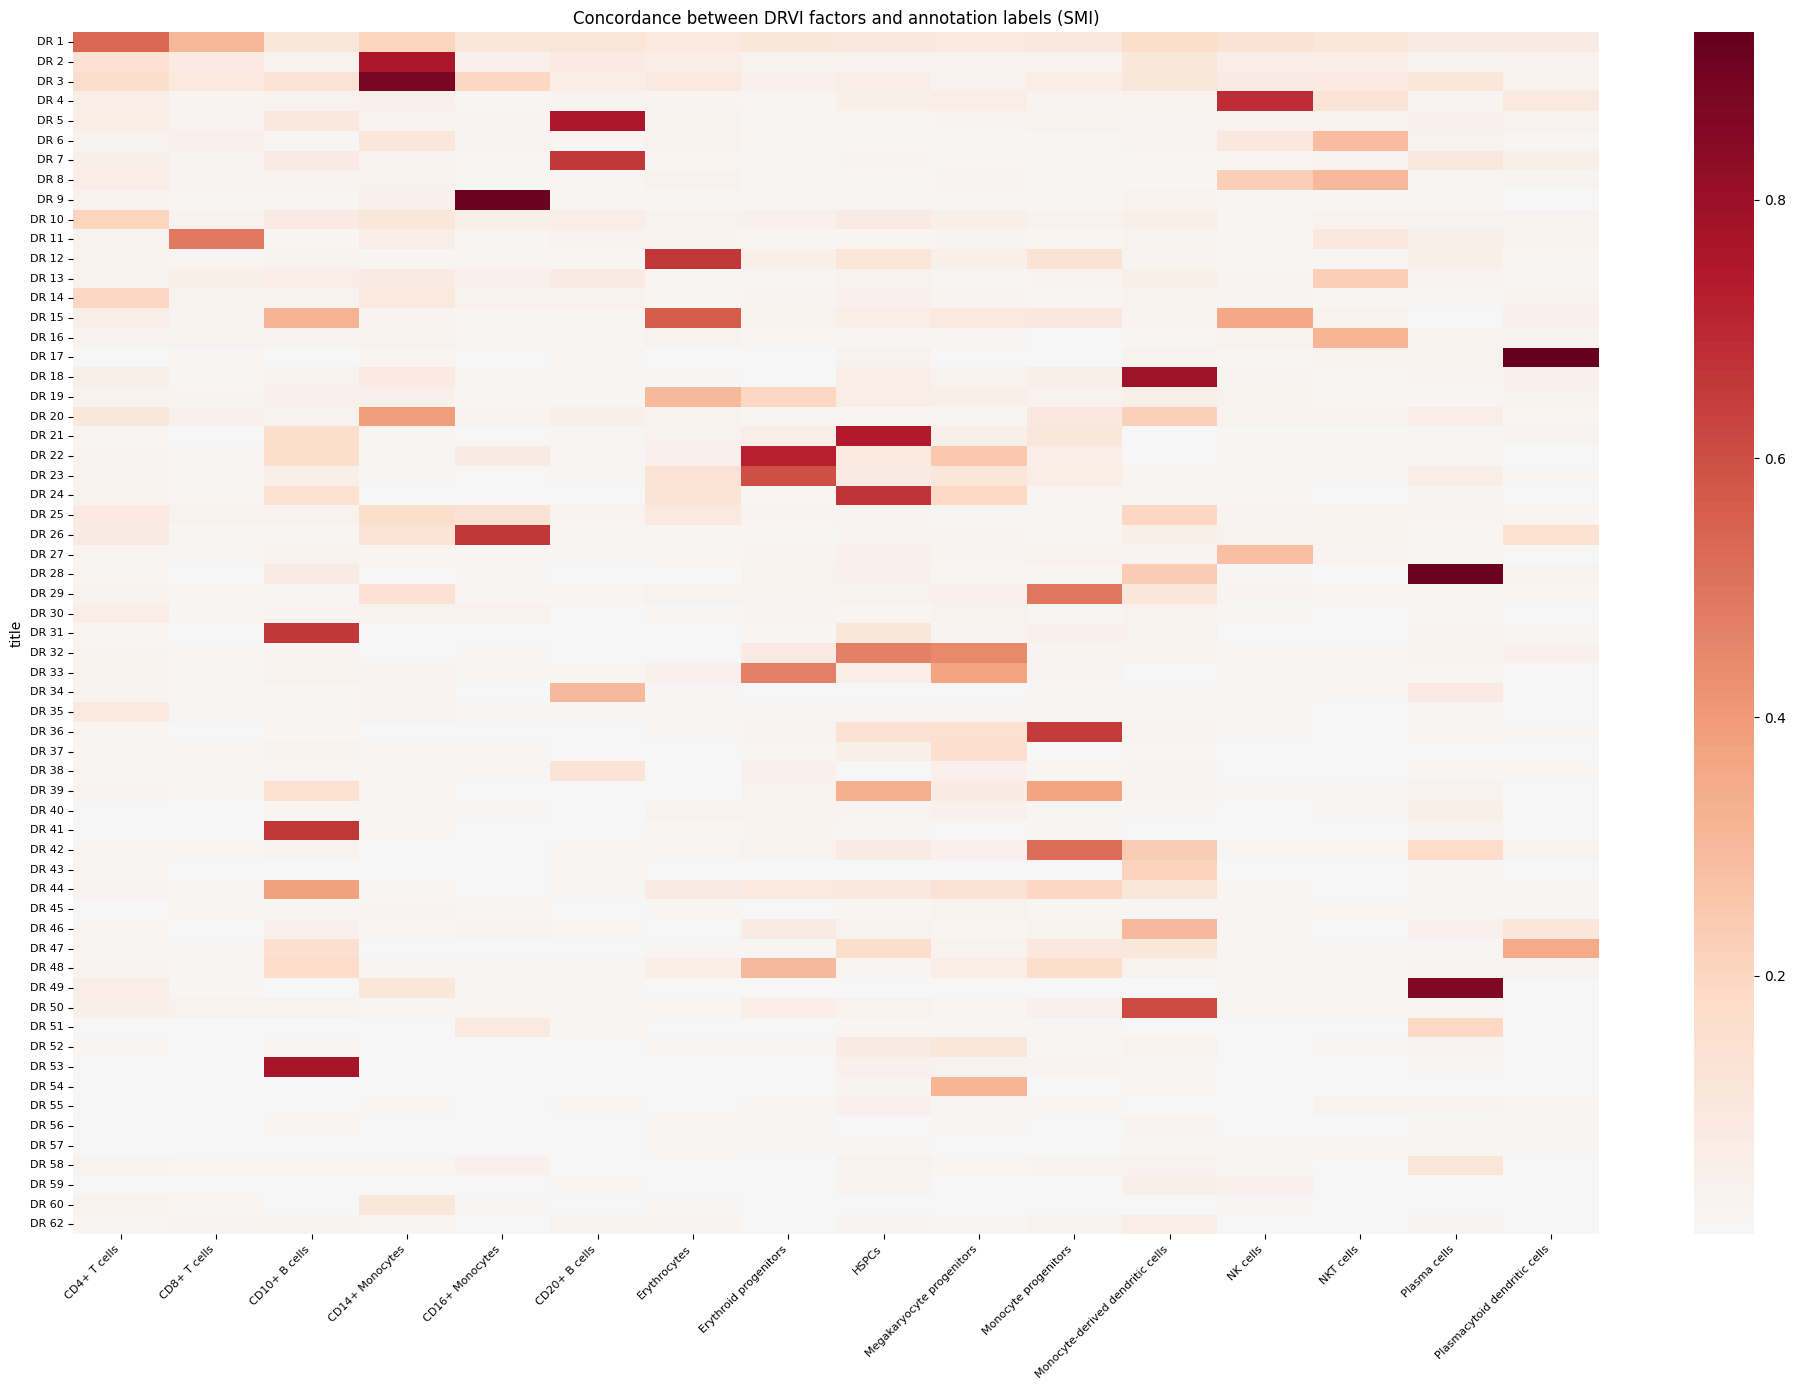

In [100]:
#Visualize with heatmap
smi_sorted = smi.copy()
smi_sorted = smi_sorted.loc[
    sorted(
        smi_sorted.index,
        key=lambda x: int(str(x).replace("DR", "").strip()) if str(x).replace("DR", "").strip().isdigit() else 10**9
    )
]

plt.figure(figsize=(20, 14))
ax = sns.heatmap(smi_sorted, cmap="RdBu_r", center=0)

ax.set_yticks(np.arange(smi_sorted.shape[0]) + 0.5)
ax.set_yticklabels(smi_sorted.index, rotation=0, fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.title("Concordance between DRVI factors and annotation labels (SMI)")
plt.tight_layout()
plt.show()

#### CellTypist Validation

In [101]:
factor_to_check = "DR 36"
adata.obs["factor_check"] = drvi_factors[factor_to_check].reindex(adata.obs_names)

UMAP

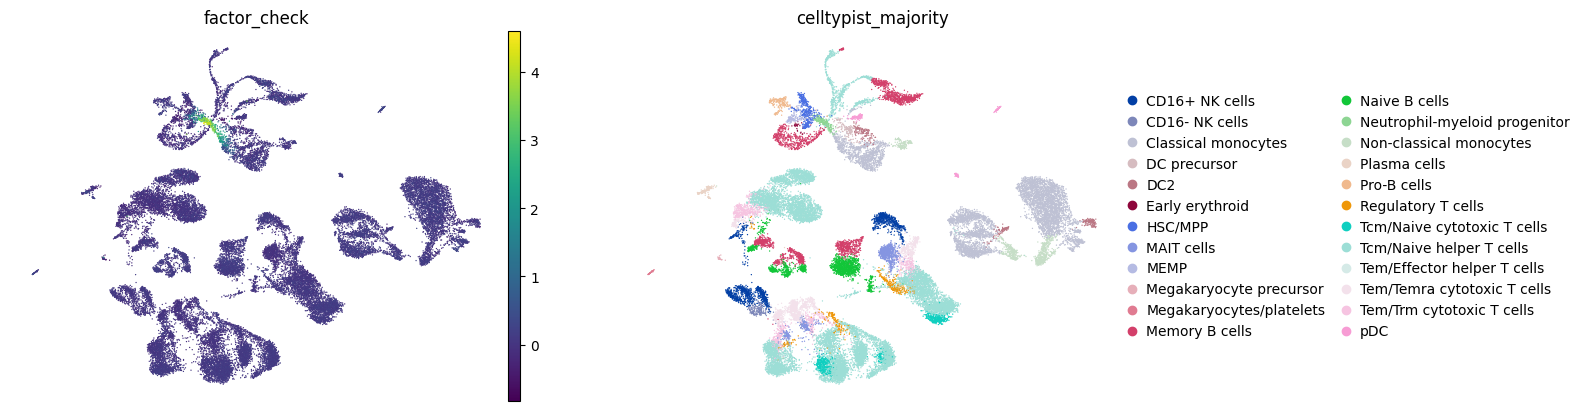

In [102]:
sc.pl.umap(
    adata,
    color=["factor_check", "celltypist_majority"],
    ncols=2,
    frameon=False,
    cmap="viridis",
)


Violin Plot

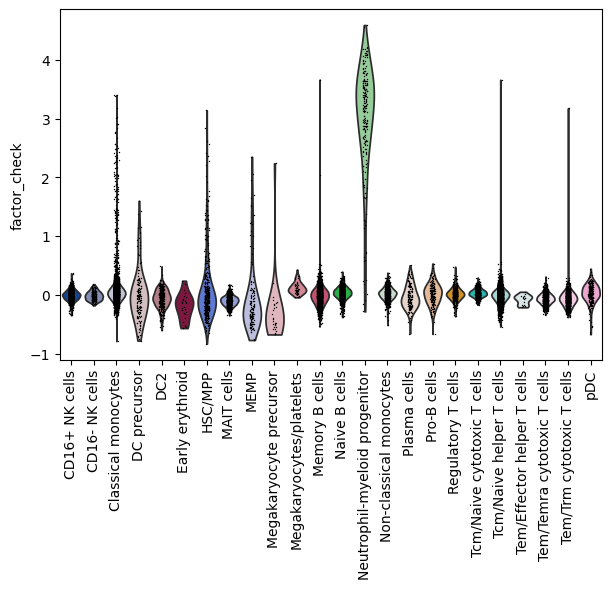

In [103]:
sc.pl.violin(
    adata,
    keys="factor_check",
    groupby="celltypist_majority",
    rotation=90
)

#### CellTypist Summary

In [104]:
# Compute specificity: how uniquely a factor maps to its top cell type.
# Specificity = SMI(best) - SMI(second-best).
# High specificity means the factor is specific to one cell type;
# low specificity suggests the factor captures variation shared across types.
top_1 = smi.idxmax(axis=1)
top_1_val = smi.max(axis=1)

tmp = smi.copy()
for i, c in enumerate(top_1):
    tmp.iloc[i, tmp.columns.get_loc(c)] = -1

specificity = top_1_val - tmp.max(axis=1)

celltypist_summary = pd.DataFrame({
    "Factor": smi.index,
    "Top_CellType": top_1.values,
    "SMI-value": top_1_val.values,   # hier: SMI-Score
    "Specificity": specificity.values,
})

celltypist_summary["Tool"] = "SMI"
celltypist_summary["Label_std"] = (
    celltypist_summary["Top_CellType"].astype(str)
    .str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
)
celltypist_summary["Significant"] = (
    (celltypist_summary["SMI-value"] >= CT_CORR_THRESHOLD)
    & (celltypist_summary["Specificity"] >= CT_SPEC_THRESHOLD)
)

display(celltypist_summary[celltypist_summary["Significant"]].head(20))

,Factor,Top_CellType,SMI-value,Specificity,Tool,Label_std,Significant
0,DR 36,Monocyte progenitors,0.652945,0.505441,SMI,monocyte_progenitors,True
1,DR 49,Plasma cells,0.859131,0.744023,SMI,plasma_cells,True
4,DR 2,CD14+ Monocytes,0.761070,0.620771,SMI,cd14_monocytes,True
5,DR 41,CD10+ B cells,0.668039,0.642334,SMI,cd10_b_cells,True
12,DR 29,Monocyte progenitors,0.495314,0.355487,SMI,monocyte_progenitors,True
13,DR 50,Monocyte-derived dendritic cells,0.609541,0.548011,SMI,monocyte_derived_dendritic_cells,True
14,DR 1,CD4+ T cells,0.535119,0.222924,SMI,cd4_t_cells,True
17,DR 5,CD20+ B cells,0.758002,0.660248,SMI,cd20_b_cells,True
23,DR 3,CD14+ Monocytes,0.878655,0.682051,SMI,cd14_monocytes,True
25,DR 11,CD8+ T cells,0.490036,0.388470,SMI,cd8_t_cells,True


### 1.2 GPTCellType

How it works:

* Input: Top-ranked marker genes (e.g., top 10–50 genes from DRVI factor loadings) and basic metadata (tissue type and species)
* Reference: 
    * Internal LLM Knowledge: Relies entirely on the pre-trained generative parameters of a single Large Language Model (typically GPT-4 or GPT-4o)
    * Textual Priors: Uses the massive corpus of biomedical literature, textbooks, and database descriptions seen during the model's training phase
* Algorithm: 
    * Direct Prompting: The gene list is formatted into a specialized prompt (e.g., "Assign a cell type or biological process to these genes...")
    * Zero-Shot Heuristics: The model performs a semantic match between the input gene symbols and its internal "memory" of gene functions
    * Single-Pass Logic: Unlike agent-based models, it makes a one-shot decision based on the probability of the next tokens in the sequence
* Output: 
    * Identity Label: A concise name for the cell type or biological program (factor)
    * Brief Rationale: A short text snippet explaining the roles of the key genes that led to the identification
    * Top Marker Alignment: A list showing which input genes most strongly support the assigned label

### 1.3 mLLM CellType

How it works:

* Input: Differentially expressed marker genes (e.g., from FindAllMarkers) and critical metadata like tissue context (e.g., "human brain"), species, and experimental condition
* Reference: 
    * Collective Intelligence: Does not rely on a single database; instead, it synthesizes knowledge from an ensemble of SOTA models (e.g., GPT-5.2, Claude 4.5, Gemini 3 Pro, Qwen3)
    * Zero-Shot Learning: Functions without a pre-existing reference atlas by tapping into the models' internal biomedical training data
* Algorithm: 
    * Initial Annotation: Multiple LLMs independently propose cell type labels and provide biological reasoning for their choice
    * Structured Deliberation: For clusters where models disagree (controversial clusters), the framework initiates a "discussion" phase. Models share their reasoning and cross-evaluate each other's arguments
    * Consensus Checker (CC): A lead model (e.g., Claude 4.5 or GPT-5) acts as a moderator to synthesize the discussion and reach a final consensus
    * Uncertainty Quantification: It calculates the Consensus Proportion (CP) (level of agreement) and Shannon Entropy (H) (diversity of opinions) to flag ambiguous results for human review
* Output: 
    * Consensus Label: The most probable cell type agreed upon by the ensemble
    * Uncertainty Metrics: CP and Shannon Entropy values for every cluster
    * Full Reasoning Log: A transparent record of the debate between models, documenting why specific markers led to the final label

#### Settings/Imports

### 1.4 DeepCellSeek

How it works:

* Input: Ranked marker gene lists (top loadings) and specific "Niche" information (e.g., "Human Gut - Inflammatory Bowel Disease")
* Reference: 
    * Multi-LLM Ensemble: Queries a "Council" of the latest models (e.g., GPT-5, Claude 4.1, and Gemini 2 Ultra)
    * Consensus Database: Aggregates knowledge from established ontologies (CL, MeSH) and recent publication pre-prints
* Algorithm: 
    * Systematic Benchmarking: The tool was built by benchmarking 34 datasets to identify the "optimal" prompt engineering for cell annotation
    * Majority Voting: It sends the same gene list to multiple LLMs and uses a weighted voting system to determine the final label
    * Subtype Resolution: It specifically triggers "Deep Dive" prompts when it detects ambiguity between similar cells (e.g., distinguishing different states of Macrophages)
* Output: 
    * Consensus Label: The final agreed-upon cell type name
    * Ensemble Agreement Score: A percentage showing how many of the internal models agreed on the label
    * Evidence Summary: A concise list of literature-backed reasons why specific markers (from your DRVI list) point to the chosen label

### 1.5 CellAgent

How it works:

* Input: High-confidence marker gene lists (e.g., top genes from DRVI factor loadings) and study metadata (e.g., tissue type, species)
* Reference: 
    * External Knowledge Integration: Actively queries curated databases like CellMarker, PanglaoDB, and Azimuth
    * Internal LLM Corpus: Leverages the vast biological literature embedded in Large Language Models (typically GPT-4 or GPT-5)
* Algorithm: multi agent orchestration
    * The Planner: Formulates a search strategy based on the input context
    * The Executor: Retrieves evidence from databases and matches input genes against known cell-type signatures
    * The Evaluator: Critically reviews the proposed labels for biological plausibility and cross-references them with the original data
    --> Iterative Reasoning: If the Evaluator detects a mismatch (e.g., a "Muscle cell" label for a "Brain" sample), the agents enter a feedback loop to refine the search and resolve conflicts
* Output: 
    * Predicted Cell Type: The final consensus label for the cell cluster or factor
    * Confidence Score: A metric indicating the certainty of the multi-agent agreement
    * Reasoning Trace: A step-by-step logical justification (narrative) explaining the biological evidence used for the decision
    * Marker Validation: A list of specific input genes that were successfully validated against the reference databases

## 2. Annotation of Biological Processes (Funtional Identity)

Goal: Identify biological processes (e.g., "Interferon Response", "Cell Cycle") for factors that do not map 1-to-1 to a cell type.

Tools to Compare:

* Gene Set Enrichment Analysis:
    * gProfiler (gprofiler-official): The benchmark used in the DRVI preprint
    * Gseapy: Python implementation for local Enrichment analysis (Enrichr/MSigDB)
    * Decoupler: A fast framework for footprint-based enrichment (e.g., PROXIMA)
    * Blitzqseq
* LLM-based tools:
    * AnnDictionary: It provides a structured metadata framework within AnnData objects to map latent representations and gene sets to standardized biological vocabularies using LLM-backed dictionaries
    * Cell Agent: It employs a multi-agent "Plan-and-Execute" hierarchy where specialized AI agents collaborate to perform data tool manipulation, literature retrieval, and iterative biological reasoning
    * EnrichGT: It bridges classical statistics and semantics by taking raw ORA/GSEA results and using LLMs to perform intelligent clustering and context-aware summarization of biological pathways
    * Cell2Text-V2: It transforms numerical gene expression matrices and factor loadings into coherent natural language descriptions by leveraging refined prompt engineering and retrieval-augmented domain knowledge


Key Metrics:

### 2.1 Blitzqseq

How it works:
* Input: Ranked gene list (list of ALL genes sorted by loadings for a specific factor)
* Reference: Database on Enrichr
    * Key Collections: 
        * e.g MgSigDB
            * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
            * C5 (GO): Highly specific Gene Ontology terms.
            * C2 (CP): Curated pathways from Reactome or KEGG.
        * Cellmarker/Azimuth
        * Reactome/KEGG
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Speed Optimization: BlitzGSEA uses a probability distribution approximation to estimate the null model. Instead of running thousands of slow permutations for every gene set, it uses mathematical shortcuts to calculate p-values almost instantly
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * p-value & FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Leading Edge Genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### BlitzGSEA Library

In [ ]:
# MSigDB Hallmark is the gold standard for the first evaluation
signature_lib = blitz.enrichr.get_library("MSigDB_Hallmark_2020")

In [ ]:
#Return the first column name from candidates that exists in df. Handles varying column naming conventions across blitzgsea/gseapy versions
def _pick_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

##### GSEA

In [ ]:
# BlitzGSEA: fast analytic GSEA approximation.
# Input:  ranked gene list per factor (all genes sorted by descending effect score).
# Method: Approximates the running-sum statistic of classic GSEA using an analytic null distribution, avoiding permutation tests for faster execution.
# Output per gene set: NES (Normalized Enrichment Score), FDR (False Discovery Rate).
blitz_rows = []

for factor_dir, s in ranked_inputs.items():
    sig = s.dropna().reset_index()
    sig.columns = ["i", "v"]  # blitzgsea requires 2-column format: gene, score

    try:
        res = blitz.gsea(sig, signature_lib, processes=BLITZGSEA_PROCESSES)
        if res is None or res.empty:
            continue

        term = res["Term"] if "Term" in res.columns else pd.Series(res.index, index=res.index)
        fdr = res["fdr"] if "fdr" in res.columns else res["FDR"]
        nes = res["nes"] if "nes" in res.columns else res["NES"]

        blitz_rows.append(pd.DataFrame({
            "FactorDir": factor_dir,
            "Term": term.astype(str).values,
            "NES": pd.to_numeric(nes, errors="coerce").values,
            "FDR": pd.to_numeric(fdr, errors="coerce").values
        }))
    except Exception:
        pass

blitzgsea_summary = pd.concat(blitz_rows, ignore_index=True) if blitz_rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])


In [ ]:
sig_blitz = blitzgsea_summary.query("FDR < @FDR")[["FactorDir", "Term", "NES", "FDR"]].copy()
sig_blitz["Factor"] = strip_factor(sig_blitz["FactorDir"]).values
spec = compute_tool_specificity(blitzgsea_summary, "FactorDir", "NES", use_nes=True)
sig_blitz = sig_blitz.merge(annot_map, on="Factor", how="left").merge(spec, left_on="Factor", right_index=True, how="left")
display(sig_blitz.sort_values("FDR"))

,FactorDir,Term,NES,FDR,Factor,Annot_Label,Annot_SMI,Specificity
1,DR 29_pos,Pperoxisome,-5.561263,0.000001,DR 29,Monocyte progenitors,0.495,2.297872
14,DR 48_neg,KRAS Signaling Up,-4.513934,0.000305,DR 48,Erythroid progenitors,0.299,0.933472
9,DR 54_neg,IL-6/JAK/STAT3 Signaling,4.395026,0.000532,DR 54,Megakaryocyte progenitors,0.318,0.866440
23,DR 18_pos,Pperoxisome,-4.155487,0.001558,DR 18,Monocyte-derived dendritic cells,0.791,2.158132
19,DR 4_neg,Epithelial Mesenchymal Transition,3.931776,0.004047,DR 4,NK cells,0.686,0.338451
20,DR 4_neg,KRAS Signaling Up,-3.593326,0.007836,DR 4,NK cells,0.686,0.338451
15,DR 48_neg,Epithelial Mesenchymal Transition,-3.580462,0.008232,DR 48,Erythroid progenitors,0.299,0.933472
10,DR 54_neg,KRAS Signaling Up,-3.528586,0.010027,DR 54,Megakaryocyte progenitors,0.318,0.866440
17,DR 56_pos,Epithelial Mesenchymal Transition,-3.706257,0.010097,DR 56,Monocyte-derived dendritic cells,0.027,1.243241
7,DR 3_pos,KRAS Signaling Up,-3.672708,0.011520,DR 3,CD14+ Monocytes,0.879,0.195445


#### BlitzGSEA Summary

In [ ]:
annotated_blitz = blitzgsea_summary[blitzgsea_summary["FDR"] < FDR].copy() if not blitzgsea_summary.empty else pd.DataFrame()
tool_coverage_summary(blitzgsea_summary, annotated_blitz, "FactorDir", "Term", "FDR", "BlitzGSEA", effect_type="nes")

BlitzGSEA coverage (FDR<0.05): 18.33% (11/60)
Unique terms: 14
Median NES: -3.35


### 2.2 Gseapy (Preranking Module)

How it works:
* Input: 
    * Ranked gene list (list of ALL genes sorted by loadings for a specific factor) for Preranked Module [Important: Gene names have to be in capital letters]
    * Gene expression matrix and group annotation for classical module
* Reference: Database on Enrichr
    * Key Collections: 
        * e.g MgSigDB
            * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
            * C5 (GO): Highly specific Gene Ontology terms.
            * C2 (CP): Curated pathways from Reactome or KEGG.
        * Cellmarker/Azimuth
        * Reactome/KEGG
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Permutation-based Null Model: It randomly reassigns gene labels many times (default is 1000 iterations) to see how often a similar ES occurs by pure chance
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Lead_genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### Get Gene Library

In [ ]:
gseapy_lib = blitz.enrichr.get_library(GSEA_DB)
print(f"gseapy DB: {GSEA_DB} | gene sets: {len(gseapy_lib)}")

gseapy DB: MSigDB_Hallmark_2020 | gene sets: 50


#### Run Gseapy Prerank Loop


In [ ]:
# GSEApy Prerank: permutation-based GSEA.
# Input:  ranked gene list per factor (same as BlitzGSEA).
# Method: Classic Kolmogorov-Smirnov-like running-sum statistic with a permutation-based null model (GSEAPY_PERMUTATIONS shuffles) to estimate significance.
# Output per gene set: NES (Normalized Enrichment Score), FDR (q-value).
gseapy_rows = []
for factor_dir, s in ranked_inputs.items():
    rnk = s.reset_index()
    rnk.columns = ["gene", "score"]
    # Skip factors where all scores are identical (causes PanicException in gseapy)
    scores = rnk["score"].dropna()
    if scores.nunique() < 2:
        continue
    try:
        pre_res = gp.prerank(
            rnk=rnk,
            gene_sets=gseapy_lib,
            min_size=GSEAPY_MIN_SIZE,
            max_size=GSEAPY_MAX_SIZE,
            permutation_num=GSEAPY_PERMUTATIONS,
            outdir=None,
            seed=0,
            verbose=False,
        )
        res = pre_res.res2d
        if res is None or res.empty:
            continue
        term_col = _pick_col(res, ["Term", "term"])
        nes_col = _pick_col(res, ["NES", "nes"])
        fdr_col = _pick_col(res, ["FDR q-val", "FDR", "fdr"])
        if term_col is None or nes_col is None or fdr_col is None:
            continue
        tmp = pd.DataFrame(
            {
                "FactorDir": factor_dir,
                "Term": res[term_col].astype(str).values,
                "NES": pd.to_numeric(res[nes_col], errors="coerce").values,
                "FDR": pd.to_numeric(res[fdr_col], errors="coerce").values,
            }
        )
        gseapy_rows.append(tmp)
    except Exception:
        continue

gseapy_summary = pd.concat(gseapy_rows, ignore_index=True) if gseapy_rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])



2026-02-27 09:50:46,444 [WARNING] Duplicated values found in preranked stats: 91.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-27 09:50:46,925 [WARNING] Duplicated values found in preranked stats: 90.25% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-27 09:50:47,292 [WARNING] Duplicated values found in preranked stats: 89.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-27 09:50:47,630 [WARNING] Duplicated values found in preranked stats: 88.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-27 09:50:47,968 [WARNING] Duplicated values found in preranked stats: 86.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-27 09:50:48,288 [WARNING] Duplicated values found in preranked stats: 88.65% of genes
The order of those genes w

In [ ]:
sig_gseapy = gseapy_summary.query("FDR < @FDR")[["FactorDir", "Term", "NES", "FDR"]].copy()
sig_gseapy["Factor"] = strip_factor(sig_gseapy["FactorDir"]).values
spec = compute_tool_specificity(gseapy_summary, "FactorDir", "NES", use_nes=True)
sig_gseapy = sig_gseapy.merge(annot_map, on="Factor", how="left").merge(spec, left_on="Factor", right_index=True, how="left")
display(sig_gseapy.sort_values("FDR"))

,FactorDir,Term,NES,FDR,Factor,Annot_Label,Annot_SMI,Specificity
0,DR 34_pos,Adipogenesis,1.085877,0.046009,DR 34,CD20+ B cells,0.3,0.026425


#### Gseapy Summary


In [ ]:
annotated_gseapy = gseapy_summary[gseapy_summary["FDR"] < FDR].copy() if not gseapy_summary.empty else pd.DataFrame()
tool_coverage_summary(gseapy_summary, annotated_gseapy, "FactorDir", "Term", "FDR", "GSEApy", effect_type="nes")


GSEApy coverage (FDR<0.05): 1.67% (1/60)
Unique terms: 1
Median NES: 1.09


### 2.3 gprofiler

How it works:
* Input: 
    * Ordered gene list: List of genes sorted by loadings (only top list as query)
    * Background Gene Set: List of all genes that were measured in experiment
    * Identifiers: many formats can be converted by g:Convert
* Reference: broad integration of many sources (g:GOSt)
    * Gene Ontology
    * Biological Pathways: KEGG, Reactome,..
    * Regulatory Motifs: Transfaci, MIRNA
    * Protein data bases
    * ...
* Algorithm: Over Representation Analysis
    * Hypergeometric test: calculates probability that overlap is only by pure chance
    * Ordered Query: It calculates a p-value at each step and identifies the specific "cutoff" point where the enrichment significance is at its maximum (the lowest p-value)
    * g:SCS (Significance Threshold): own algorithm to correct for multiple testing, optimized for hierarchical structure of GO-terms (tighter than FDR)
* Output: 
    * p-value
    * Intersection size: how many of your genes are found in pathway
    * Manhattan plot: interactive visualization that groups results by data base

In [ ]:
gp = GProfiler(return_dataframe=True)

#### Helper function

In [ ]:
# Over-Representation Analysis (ORA) via g:Profiler.
# Input:  top-N gene list per factor direction (from build_inputs).
# Method: Hypergeometric test — tests whether the overlap between the query gene set and each annotation term is larger than expected by chance.
#Multiple testing correction uses g:SCS (Set Counts and Sizes), a method tailored for correlated, overlapping gene sets.
# Output: DataFrame with columns including 'p_value', 'name', 'source', 'factor'.
def run_gprofiler_for_gene_list(genes, factor, direction):
    genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
    if not genes:
        return pd.DataFrame()

    kwargs = dict(
        organism=GP_ORGANISM,
        query=genes,
        user_threshold=GP_USER_THRESHOLD,
        ordered=GP_ORDERED,
        background=ALL_GENES,
    )
    if GP_SOURCES:
        kwargs["sources"] = GP_SOURCES

    res = gp.profile(**kwargs)
    if res is None or res.empty:
        return pd.DataFrame()

    res = res.copy()
    res["factor"] = factor
    res["direction"] = direction
    return res

#### Run

In [ ]:
gprofiler_parts = []
for fac in factor_ids:
    gprofiler_parts.append(run_gprofiler_for_gene_list(pos_top[fac], fac, "pos"))
    gprofiler_parts.append(run_gprofiler_for_gene_list(neg_top[fac], fac, "neg"))

gprofiler_valid = [x for x in gprofiler_parts if not x.empty]
gprofiler_res = pd.concat(gprofiler_valid, ignore_index=True) if gprofiler_valid else pd.DataFrame()


In [ ]:
sig_gprof = gprofiler_res.query("p_value < @FDR").copy()
sig_gprof["Term"] = sig_gprof["name"] if "name" in sig_gprof else sig_gprof["native"]
sig_gprof = sig_gprof.rename(columns={"factor": "Factor"})
spec = compute_tool_specificity(gprofiler_res.rename(columns={"factor": "Factor"}), "Factor", "p_value")
sig_gprof = sig_gprof.merge(annot_map, on="Factor", how="left").merge(spec, left_on="Factor", right_index=True, how="left")
display(sig_gprof[["Factor", "Term", "p_value", "Specificity", "Annot_Label", "Annot_SMI"]].sort_values("p_value"))

,Factor,Term,p_value,Specificity,Annot_Label,Annot_SMI
1734,DR 2,Neutrophil degranulation,5.885770e-44,2.447749,CD14+ Monocytes,0.761
8855,DR 25,defense response,6.031815e-43,3.230669,Monocyte-derived dendritic cells,0.197
1735,DR 2,Innate Immune System,1.650261e-41,2.447749,CD14+ Monocytes,0.761
10755,DR 3,Neutrophil degranulation,7.177130e-41,0.097095,CD14+ Monocytes,0.879
10756,DR 3,Innate Immune System,8.975240e-41,0.097095,CD14+ Monocytes,0.879
...,...,...,...,...,...,...
17057,DR 14,Development and heterogeneity of the ILC family,4.996363e-02,0.292434,CD4+ T cells,0.199
17056,DR 14,Inflammatory response pathway,4.996363e-02,0.292434,CD4+ T cells,0.199
13545,DR 60,Senescence and autophagy in cancer,4.996807e-02,1.722186,CD14+ Monocytes,0.102
23082,DR 31,Repression of WNT target genes,4.999386e-02,0.609371,CD10+ B cells,0.659


#### Summary

In [ ]:
g_sig = gprofiler_res[gprofiler_res["p_value"] < FDR].copy() if not gprofiler_res.empty else pd.DataFrame()
g_terms_col = "name" if "name" in g_sig.columns else "native"
tool_coverage_summary(gprofiler_res, g_sig, "factor", g_terms_col, "p_value", "g:Profiler")




g:Profiler coverage (FDR<0.05): 100.00% (61/61)
Unique terms: 1582
Median -log10(p): 3.50


### 2.4 Decoupler

How it works:
* Input: 
    * Matrix: expects gene sets in long format (source, target, weight)
* Reference: Omnipath which is a metadata base that integrates many different data bases
    * enables access too almost every available data abse using dc.get_resource()
* Algorithm: Ensemble platform --> run different methods on same data set
    * Multivariate Linear Model: very fast and often more precise than GSEA for loadings
    * Univariate Linear Model: similar to statistical regression
    * AUCell: measure activity of gene sets in individual cells/factors\
    * ORA & GSEA
* Output: Activity Scores --> how active a process is in a factor
    * Concencus Score --> can combine different methods for more robust results

#### Load gene set

In [ ]:
gs = str(DC_GENESET).strip().lower()

if gs in ["hallmark", "msigdb_hallmark", "msigdb-hallmark", "msdib_hallmark"]:
    net = dc.op.hallmark(organism=DC_ORGANISM)

elif gs == "progeny":
    net = dc.op.progeny(organism=DC_ORGANISM)

elif gs == "dorothea":
    net = dc.op.dorothea(organism=DC_ORGANISM, levels=["A", "B", "C"])

elif gs == "collectri":
    net = dc.op.collectri(organism=DC_ORGANISM)

else:
    # any OmniPath resource name, e.g. "PanglaoDB"
    net = dc.op.resource(name=DC_GENESET, organism=DC_ORGANISM)

# Keep only required columns for decouple()
cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)

#### Runner

In [ ]:
#Footprint-based enrichment via decoupler.
# Input:  factors x genes score matrix (transposed from build_inputs output).
# Methods (configurable via DC_METHODS):
        #- ULM (Univariate Linear Model): fits y ~ x per gene set, t-statistic as score.
        #- MLM (Multivariate Linear Model): fits y ~ X for all targets simultaneously.
       # - z-score: mean z-score of gene set members.
#When DC_USE_CONSENSUS=True and multiple methods are selected, consensus p-values are computed (Stouffer's method across methods).
# Output: long-format DataFrame with columns [factor, term, p_value, direction].
def run_decouple(df_factors_by_genes: pd.DataFrame, direction: str) -> pd.DataFrame:
    mat = df_factors_by_genes.copy()
    mat.columns = mat.columns.astype(str).str.strip()
    if GENE_CASE == "upper":
        mat.columns = mat.columns.str.upper()

    mat = mat.reindex(columns=ALL_GENES, fill_value=0.0)
    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    net_use = net.copy()
    net_use["target"] = net_use["target"].astype(str).str.strip()
    if GENE_CASE == "upper":
        net_use["target"] = net_use["target"].str.upper()

    res = dc.mt.decouple(
        data=mat,
        net=net_use,
        methods=DC_METHODS,
        cons=False,
        tmin=DC_TMIN,
        verbose=False,
    )
    if DC_USE_CONSENSUS and len(DC_METHODS) > 1:
        _, pvals = dc.mt.consensus(res)
    else:
        key = f"pvals_{DC_PRIMARY_METHOD}"
        if key not in res:
            return pd.DataFrame(columns=["factor", "term", "p_value", "direction"])
        pvals = res[key]

    out = pvals.stack().rename("p_value").reset_index()
    out.columns = ["factor", "term", "p_value"]
    out["direction"] = direction
    return out

#### Run

In [ ]:
dec_pos = run_decouple(pos_std.T, "pos")
dec_neg = run_decouple(neg_std.T, "neg")
decoupler_res = pd.concat([dec_pos, dec_neg], ignore_index=True)

print("rows:", len(decoupler_res))
print("unique factors:", strip_factor(decoupler_res["factor"]).nunique())
print("unique terms:", decoupler_res["term"].nunique())
print("significant rows:", (decoupler_res["p_value"] < FDR).sum())

rows: 3133
unique factors: 60
unique terms: 48
significant rows: 6


In [ ]:
sig_dec = decoupler_res.query("p_value < @FDR")[["factor", "term", "p_value"]].copy()
sig_dec = sig_dec.rename(columns={"factor": "Factor"})
spec = compute_tool_specificity(decoupler_res.rename(columns={"factor": "Factor"}), "Factor", "p_value")
sig_dec = sig_dec.merge(annot_map, on="Factor", how="left").merge(spec, left_on="Factor", right_index=True, how="left")
display(sig_dec.sort_values("p_value"))

,Factor,term,p_value,Annot_Label,Annot_SMI,Specificity
3,DR 23,HEME_METABOLISM,0.002496,Erythroid progenitors,0.597,2.196492
0,DR 40,TNFA_SIGNALING_VIA_NFKB,0.003033,Plasma cells,0.054,2.126263
5,DR 15,HEME_METABOLISM,0.004615,Erythrocytes,0.562,2.278283
1,DR 19,HEME_METABOLISM,0.011501,Erythrocytes,0.302,1.740326
2,DR 54,COAGULATION,0.043599,Megakaryocyte progenitors,0.318,1.256179
4,DR 11,ALLOGRAFT_REJECTION,0.047213,CD8+ T cells,0.490,1.256557


#### Summary

In [ ]:
d_sig = decoupler_res[decoupler_res["p_value"] < FDR].copy() if not decoupler_res.empty else pd.DataFrame()
tool_coverage_summary(decoupler_res, d_sig, "factor", "term", "p_value", "decoupler")

decoupler coverage (FDR<0.05): 10.00% (6/60)
Unique terms: 4
Median -log10(p): 2.14


### Summary of results across tools

#### Top-hit Table (Alignment Check)

In [ ]:
#Extract the top significant hit per factor for a given tool.
#Consolidates the per-tool top_*_sig functions into one reusable helper.
#For each factor, selects the hit with the lowest p-value (or highest NES) that passes the significance threshold. Used to build the cross-tool alignment table below.

def _top_sig(df, sig_col, sig_thresh, factor_col, term_col, score_col, tool_name, score_fmt=None):

    if df is None or df.empty:
        return pd.DataFrame(columns=["factor", tool_name])
    x = df[df[sig_col] < sig_thresh].copy()
    if x.empty:
        return pd.DataFrame(columns=["factor", tool_name])
    x["factor"] = strip_factor(x[factor_col]).values
    x = x.sort_values(sig_col).groupby("factor", as_index=False).head(1)
    if score_fmt == "nes":
        x[tool_name] = x[term_col].astype(str) + " | NES=" + x[score_col].round(2).astype(str)
    elif score_fmt == "corr":
        x[tool_name] = x[term_col].astype(str) + " | corr=" + x[score_col].round(2).astype(str)
    else:
        x[tool_name] = x[term_col].astype(str) + " | p=" + x[sig_col].map(lambda v: f"{v:.2e}")
    return x[["factor", tool_name]]


def top_celltypist_sig(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=["factor", "celltypist"])
    fac_col = "Factor" if "Factor" in df.columns else "factor"
    ct_col = "Top_CellType" if "Top_CellType" in df.columns else "CellType"
    corr_col = "Correlation" if "Correlation" in df.columns else "SMI-value"
    x = df[(df[corr_col] >= CT_CORR_THRESHOLD) & (df["Specificity"] >= CT_SPEC_THRESHOLD)].copy()
    if x.empty:
        return pd.DataFrame(columns=["factor", "celltypist"])
    x["factor"] = strip_factor(x[fac_col]).values
    x = x.sort_values(corr_col, ascending=False).groupby("factor", as_index=False).head(1)
    x["celltypist"] = x[ct_col].astype(str) + " | corr=" + x[corr_col].round(2).astype(str)
    return x[["factor", "celltypist"]]


def top_annotation_sig(smi_df, label_col="annotation"):
    if smi_df is None or smi_df.empty:
        return pd.DataFrame(columns=["factor", label_col])
    x = smi_df.copy()
    top_label = x.idxmax(axis=1)
    top_smi = x.max(axis=1)
    out = pd.DataFrame({
        "factor": strip_factor(top_label.index.astype(str)).values,
        label_col: top_label.values.astype(str) + " | SMI=" + top_smi.round(2).astype(str),
    })
    return out

m = _top_sig(gseapy_summary, "FDR", FDR, "FactorDir", "Term", "NES", "gseapy", score_fmt="nes")
m = m.merge(_top_sig(blitzgsea_summary, "FDR", FDR, "FactorDir", "Term", "NES", "blitzgsea", score_fmt="nes"), on="factor", how="outer")

gprof_term_col = "name" if "name" in gprofiler_res.columns else "native"
m = m.merge(_top_sig(gprofiler_res, "p_value", FDR, "factor", gprof_term_col, "p_value", "gprofiler"), on="factor", how="outer")
m = m.merge(_top_sig(decoupler_res, "p_value", FDR, "factor", "term", "p_value", "decoupler"), on="factor", how="outer")
m = m.merge(top_celltypist_sig(celltypist_summary), on="factor", how="outer")
m = m.merge(top_annotation_sig(smi_similarity), on="factor", how="outer")

eval_matrix_sig = m.sort_values("factor").set_index("factor")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

display(eval_matrix_sig.dropna(how="all"))

,gseapy,blitzgsea,gprofiler,decoupler,celltypist,annotation
factor,,,,,,
DR 1,NaN,NaN,T cell activation | p=2.14e-23,NaN,CD4+ T cells | corr=0.54,CD4+ T cells | SMI=0.54
DR 10,NaN,NaN,T cell activation | p=6.06e-22,NaN,NaN,CD4+ T cells | SMI=0.21
DR 11,NaN,NaN,immune system process | p=8.45e-21,ALLOGRAFT_REJECTION | p=4.72e-02,CD8+ T cells | corr=0.49,CD8+ T cells | SMI=0.49
DR 12,NaN,NaN,immune system process | p=8.45e-21,NaN,Erythrocytes | corr=0.66,Erythrocytes | SMI=0.66
DR 13,NaN,NaN,T cell activation | p=2.57e-25,NaN,NaN,NKT cells | SMI=0.23
DR 14,NaN,Hedgehog Signaling | NES=-3.33,lymphocyte activation | p=1.62e-25,NaN,NaN,CD4+ T cells | SMI=0.2
DR 15,NaN,NaN,immune system process | p=8.45e-21,HEME_METABOLISM | p=4.61e-03,Erythrocytes | corr=0.56,Erythrocytes | SMI=0.56
DR 16,NaN,NaN,immune response | p=3.78e-26,NaN,NaN,NKT cells | SMI=0.32
DR 17,NaN,NaN,immune response | p=1.00e-23,NaN,Plasmacytoid dendritic cells | corr=0.93,Plasmacytoid dendritic cells | SMI=0.93


#### Consistency Heatmap (Rank Correlation)

In [ ]:
# Build consistency heatmap: compare term rankings across tools.
# For each tool, -log10(p-value) scores are computed per factor-term pair.
# Terms are ranked within each tool, and Spearman rank correlation between
# tools measures how consistently they identify the same biological programs.
TOP_K = 20    # Number of top-ranked terms to include in the heatmap
FACTOR_FILTER = None

#  Normalize term names (lowercase, replace non-alphanumeric with underscore)
def norm_term(s):
    return (pd.Series(s).astype(str).str.lower()
            .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))

tool_configs = [
    ("gseapy", "gseapy_summary", "FactorDir", "Term", "FDR"),
    ("blitzgsea", "blitzgsea_summary", "FactorDir", "Term", "FDR"),
    ("gprofiler", "gprofiler_res", "factor", None, "p_value"),
    ("decoupler", "decoupler_res", "factor", "term", "p_value"),
]

parts = []
for tool, var_name, fac_col, term_col, score_col in tool_configs:
    df = globals().get(var_name)
    if df is None or df.empty:
        continue
    x = df.copy()
    if term_col is None:
        term_col = "name" if "name" in x.columns else "native"
    x["factor"] = strip_factor(x[fac_col])
    x["term"] = norm_term(x[term_col])
    x["score"] = -np.log10(pd.to_numeric(x[score_col], errors="coerce"))
    x["tool"] = tool
    parts.append(x[["tool", "factor", "term", "score"]])

rank_df = pd.concat(parts, ignore_index=True).dropna(subset=["score"])
if FACTOR_FILTER is not None:
    rank_df = rank_df[rank_df["factor"] == FACTOR_FILTER].copy()

rank_df = rank_df.groupby(["tool", "term"], as_index=False)["score"].max()
rank_df["rank"] = rank_df.groupby("tool")["score"].rank(ascending=False, method="dense")
rank_df.head()


,tool,term,score,rank
0,blitzgsea,adipogenesis,0.450970,26.0
1,blitzgsea,allograft_rejection,1.748116,5.0
2,blitzgsea,androgen_response,1.455610,9.0
3,blitzgsea,angiogenesis,1.612830,7.0
4,blitzgsea,apical_junction,0.393067,31.0


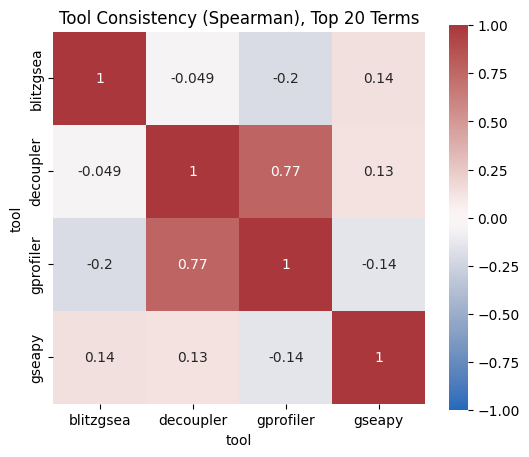

In [ ]:
# Pivot to a term x tool rank matrix and compute pairwise Spearman correlation.
# Spearman's rho measures monotonic agreement between rank orderings:
# rho = 1 means tools rank terms identically, rho = 0 means no agreement.
top_terms = rank_df[rank_df["rank"] <= TOP_K]["term"].unique()
r = rank_df[rank_df["term"].isin(top_terms)].copy()

rank_mat = r.pivot(index="term", columns="tool", values="rank")
corr = rank_mat.corr(method="spearman", min_periods=3)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="vlag", square=True)
plt.title(f"Tool Consistency (Spearman), Top {TOP_K} Terms" + (f" | {FACTOR_FILTER}" if FACTOR_FILTER else ""))
plt.show()

#### Leading-Edge-Gen-Overlap

#### Computing Time

### 3. Language Model Based Identification (Advanced Annotation)

Goal: Automate "narrative" annotation and validation using LLMs.

Tools to Compare:
* Cell Type Annotation:
    * GPTCelltype
    * scGPT
    * Geneformer
    * CellTypeAgent
* Biological Process:
    * AnnDicitionary
    * AIGE
    * 
* gsai (Gene Set AI): Specialized LLM tool for gene list interpretation.
* Celltypeagent: 
* CASSIA:
* scagent:
* CyteType:

* Direct LLM Prompting: Using GPT-4/Claude via API to summarize factor-defining genes.
* OpenScholar: For literature-backed validation of the proposed factor names.

Key Metrics:

#### 3.1 Gsai

### 4. Final Integration & Verification

Goal: Create the final notebook structure to guide the user.

Implementation:
* Unified API: A single function to call all three categories and present a summary table.
* Verify Cells: Visual sanity checks (UMAPs + Dotplots) to verify that a factor's activity matches the assigned name.
* Filtering: Automating the exclusion of "Vanished Factors" (max absolute value < 1) to reduce noise.